<a href="https://colab.research.google.com/github/Mahiman001/Data-Science-learning-practice/blob/main/2_learning_to_create_pipelines_in_sklearn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from pathlib import Path

In [ ]:
data_path  =  Path("/content/real_estate_dataset.csv")
df = pd.read_csv(data_path)

In [ ]:
df.shape

(500, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  500 non-null    int64  
 1   Square_Feet         500 non-null    float64
 2   Num_Bedrooms        500 non-null    int64  
 3   Num_Bathrooms       500 non-null    int64  
 4   Num_Floors          500 non-null    int64  
 5   Year_Built          500 non-null    int64  
 6   Has_Garden          500 non-null    int64  
 7   Has_Pool            500 non-null    int64  
 8   Garage_Size         500 non-null    int64  
 9   Location_Score      500 non-null    float64
 10  Distance_to_Center  500 non-null    float64
 11  Price               500 non-null    float64
dtypes: float64(4), int64(8)
memory usage: 47.0 KB


In [ ]:
df.describe()

,ID,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,Has_Garden,Has_Pool,Garage_Size,Location_Score,Distance_to_Center,Price
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,174.640428,2.958000,1.976000,1.964000,1957.604000,0.536000,0.492000,30.174000,5.164410,10.469641,582209.629529
std,144.481833,74.672102,1.440968,0.820225,0.802491,35.491781,0.499202,0.500437,11.582575,2.853489,5.588197,122273.390345
min,1.000000,51.265396,1.000000,1.000000,1.000000,1900.000000,0.000000,0.000000,10.000000,0.004428,0.062818,276892.470136
25%,125.750000,110.319923,2.000000,1.000000,1.000000,1926.000000,0.000000,0.000000,20.000000,2.760650,6.066754,503080.344140
50%,250.500000,178.290937,3.000000,2.000000,2.000000,1959.000000,1.000000,0.000000,30.000000,5.206518,10.886066,574724.113347
75%,375.250000,239.031220,4.000000,3.000000,3.000000,1988.000000,1.000000,1.000000,41.000000,7.732933,15.072590,665942.301274
max,500.000000,298.241199,5.000000,3.000000,3.000000,2022.000000,1.000000,1.000000,49.000000,9.995439,19.927966,960678.274291


In [ ]:
print(df.columns.tolist())

['ID', 'Square_Feet', 'Num_Bedrooms', 'Num_Bathrooms', 'Num_Floors', 'Year_Built', 'Has_Garden', 'Has_Pool', 'Garage_Size', 'Location_Score', 'Distance_to_Center', 'Price']


In [ ]:
print(df.dtypes)

ID                      int64
Square_Feet           float64
Num_Bedrooms            int64
Num_Bathrooms           int64
Num_Floors              int64
Year_Built              int64
Has_Garden              int64
Has_Pool                int64
Garage_Size             int64
Location_Score        float64
Distance_to_Center    float64
Price                 float64
dtype: object


In [ ]:
print(df.isnull().sum())

ID                    0
Square_Feet           0
Num_Bedrooms          0
Num_Bathrooms         0
Num_Floors            0
Year_Built            0
Has_Garden            0
Has_Pool              0
Garage_Size           0
Location_Score        0
Distance_to_Center    0
Price                 0
dtype: int64


In [ ]:
df.head()

,ID,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,Has_Garden,Has_Pool,Garage_Size,Location_Score,Distance_to_Center,Price
0,1,143.635030,1,3,3,1967,1,1,48,8.297631,5.935734,602134.816747
1,2,287.678577,1,2,1,1949,0,1,37,6.061466,10.827392,591425.135386
2,3,232.998485,1,3,2,1923,1,0,14,2.911442,6.904599,464478.696880
3,4,199.664621,5,2,2,1918,0,0,17,2.070949,8.284019,583105.655996
4,5,89.004660,4,3,3,1999,1,0,34,1.523278,14.648277,619879.142523


In [ ]:
df['Price'].mean()

np.float64(582209.6295285609)

In [ ]:
print(df.corr())

                          ID  Square_Feet  ...  Distance_to_Center     Price
ID                  1.000000     0.051102  ...           -0.006751  0.031774
Square_Feet         0.051102     1.000000  ...            0.093080  0.558604
Num_Bedrooms        0.014511    -0.049918  ...            0.040511  0.563973
Num_Bathrooms       0.027395    -0.001667  ...           -0.082571  0.156689
Num_Floors         -0.006343     0.056873  ...            0.035164  0.177435
Year_Built          0.028548    -0.055062  ...           -0.015113  0.418293
Has_Garden         -0.005307    -0.000978  ...            0.040305  0.109196
Has_Pool           -0.076580     0.007530  ...            0.110382  0.136579
Garage_Size        -0.000137    -0.051598  ...           -0.061407  0.032100
Location_Score     -0.045071    -0.035270  ...            0.054446  0.071326
Distance_to_Center -0.006751     0.093080  ...            1.000000  0.000730
Price               0.031774     0.558604  ...            0.000730  1.000000

In [ ]:
target = "Price"
x = df.drop(columns =[target,"ID"])
y = df[target]

In [ ]:
print(x.shape)
print(y.shape)
print(x.columns)


(500, 10)
(500,)
Index(['Square_Feet', 'Num_Bedrooms', 'Num_Bathrooms', 'Num_Floors',
       'Year_Built', 'Has_Garden', 'Has_Pool', 'Garage_Size', 'Location_Score',
       'Distance_to_Center'],
      dtype='object')


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size= 0.33,random_state=45)

In [ ]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(335, 10)
(165, 10)
(335,)
(165,)


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [ ]:
numerical_transformer  = Pipeline(steps =[("imputer",SimpleImputer(strategy="median")),
("scaler",StandardScaler())])

In [ ]:
from sklearn.linear_model import LinearRegression
pipeline =  Pipeline(steps =[("preprocessor",numerical_transformer,),("model",LinearRegression())])

In [ ]:
pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                                 ('scaler', StandardScaler())])),
                ('model', LinearRegression())])

In [ ]:
y_pred = pipeline.predict(x_test)

In [ ]:
y_pred[:5]

array([654615.1919226 , 728006.84088919, 627179.39552452, 788197.27081628,
       604089.19850216])

In [ ]:
#############################   MODEL EVALUATION ##################################################
################################  MAE, MSE ,RMSE , R2###########################################3


In [ ]:
####################   MAE (MEAN ABSOLUTE ERROR )  #######################
  #         mae tells us  on average how far our predictions are from the actual  values            #

from sklearn.metrics import mean_absolute_error

MAE = mean_absolute_error(y_test,y_pred)
print(MAE)

# the value we got got is 16007  whuch means we are this much off from the actual predictions

16007.094379711038


In [ ]:
from sklearn.metrics import mean_squared_error
RMSE = mean_squared_error(y_test,y_pred)**0.5
print(RMSE)

###########33  HERE WE USED RMSE BECAUSE IN MSE THE ERROR IS SQUARED SO ITS harder to interpret.  ########

20411.366996571032


In [ ]:
####3  WE ARE USNG R2 SCORE , IT TELL US HOW MUCH VARIATION IN HOUSE PRICE IS EXPLAINED BY OUR MODEL


from sklearn.metrics import r2_score
R2 = r2_score(y_test,y_pred)
print(R2)

0.9744061547915785


In [ ]:
############### now we'll learn cross validation ################
from sklearn.model_selection import cross_val_score
cv_score = cross_val_score(pipeline,
                           x_train,
                           y_train,
                           cv=5,
                           scoring ='r2')

print(cv_score)
print(cv_score.mean())
###### we used cv, basically what it does is if we put cv= 5 it will split x_train in 5 equal subsets,
###### and perform  the scoring method  we used on these and cross validate and we'll actually be
######  confident in the test we performed.################################################

[0.97450518 0.97185277 0.97741234 0.97522342 0.97220675]
0.9742400926114737


In [ ]:
##########333  NOW WE'LL DO RESIDUAL ANALYSIS ##########
residuals = y_test-y_pred
print(residuals.head())


204   -16819.757680
481     4604.555265
296    -8999.864473
38    -38342.211450
298   -34545.294034
Name: Price, dtype: float64


In [ ]:
print(residuals.describe())

count      165.000000
mean     -1477.094000
std      20419.823259
min     -62654.667874
25%     -13926.273595
50%       -710.915589
75%      11177.585343
max      49772.233980
Name: Price, dtype: float64


In [ ]:
# count
# → Number of residuals / predictions being evaluated.

# mean
# → Average error.
# → Close to 0 = little overall prediction bias.
# → Negative = model tends to overpredict.
# → Positive = model tends to underpredict.

# std
# → Spread of the errors.
# → Smaller = errors are more consistently close to the mean.

# min
# → Largest negative residual.
# → Biggest overprediction.

# 25%
# → 25% of residuals are below this value.
# → First quartile (Q1).

# 50%
# → Median residual.
# → 50% of residuals are below this value.
# → Close to 0 = predictions are generally centered around actual values.

# 75%
# → 75% of residuals are below this value.
# → Third quartile (Q3).

# max
# → Largest positive residual.
# → Biggest underprediction.

# residual = actual - predicted

# negative residual → predicted too HIGH
# positive residual → predicted too LOW

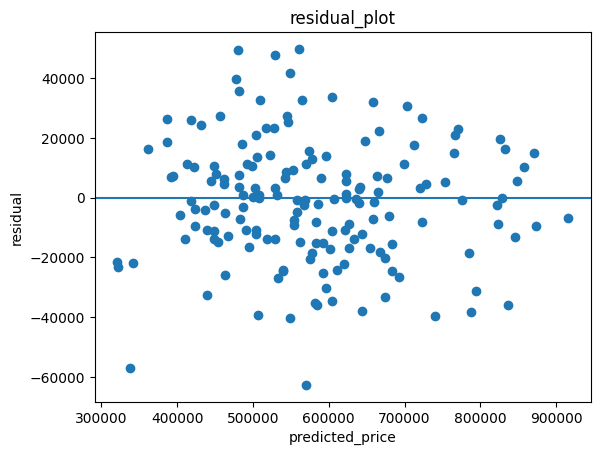

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(y_pred,residuals)
plt.axhline(y=0)
plt.xlabel("predicted_price")
plt.ylabel("residual")
plt.title("residual_plot")
plt.show()